# Predictive Modeling of CO2 Emissions

This notebook focuses on building and optimizing de um modelo de regressão para prever emissões de CO2, utilizando pipelines de pré-processamento sofisticados e busca de hiperparâmetros.

## 1. Imports and Parameters

We load the necessary libraries, com foco em scikit-learn para preprocessing e modelagem.

In [1]:
# Imports and path configurations
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    MinMaxScaler,
    OrdinalEncoder,
    OneHotEncoder,
    PowerTransformer,
    QuantileTransformer,
)

# baseline model
from sklearn.dummy import DummyRegressor

# linear models
from sklearn.linear_model import Lasso, LinearRegression, Ridge

# tree-based models
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# SVM
from sklearn.svm import LinearSVR

# kNN
from sklearn.neighbors import KNeighborsRegressor

# for exporting the model
from joblib import dump

from src.helpers import get_coefficients_dataframe
from src.config import PROCESSED_DATA, FINAL_MODEL
from src.plots import (
    plot_coefficients,
    plot_model_metrics_comparison,
    plot_estimator_residuals,
)
from src.models import (
    organize_results,
    train_and_validate_regression_model,
    run_grid_search_cv,
    RANDOM_STATE,
)

## 3. Data Loading

We read the processed data and separate variables explicativas (X) do alvo (y).

In [2]:
# Loading data and feature/target separation
df = pd.read_parquet(PROCESSED_DATA)

df.head()

,model_year,transmission,fuel_type,city_l_100_km,highway_l_100_km,combined_l_100_km,co2_emissions_g_km,vehicle_class_grouped,engine_size_l_class,cylinders_class
0,2005,A,reg_gasoline,9.2,7.2,8.3,191,car,up_to_2,up_to_4
1,2005,M,reg_gasoline,9.1,7.3,8.3,191,car,up_to_2,up_to_4
2,2005,A,premium_gasoline,15.9,11.1,13.7,315,suv,up_to_4,up_to_6
3,2005,AS,premium_gasoline,15.1,10.5,13.0,299,car,up_to_4,up_to_6
4,2005,M,premium_gasoline,15.1,10.5,13.0,299,car,up_to_4,up_to_6


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20520 entries, 0 to 20519
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   model_year             20520 non-null  int64   
 1   transmission           20520 non-null  object  
 2   fuel_type              20520 non-null  object  
 3   city_l_100_km          20520 non-null  float64 
 4   highway_l_100_km       20520 non-null  float64 
 5   combined_l_100_km      20520 non-null  float64 
 6   co2_emissions_g_km     20520 non-null  int64   
 7   vehicle_class_grouped  20520 non-null  object  
 8   engine_size_l_class    20520 non-null  category
 9   cylinders_class        20520 non-null  category
dtypes: category(2), float64(3), int64(2), object(3)
memory usage: 1.3+ MB


In [4]:
target_column = ["co2_emissions_g_km"]

ordinal_columns = ["engine_size_l_class", "cylinders_class"]

ohe_columns = ["transmission", "fuel_type", "vehicle_class_grouped"]

min_max_column = ["model_year"]

power_transform_columns = ["city_l_100_km", "highway_l_100_km", "combined_l_100_km"]

## 4. Preparing the Preprocessing Pipeline

We configure different transformers for each variable type (categórica, numérica, classes).

In [5]:
# ColumnTransformer configuration for preprocessing
preprocessing = ColumnTransformer(
    transformers=[
        ("ordinal", OrdinalEncoder(categories="auto"), ordinal_columns),
        ("onehot", OneHotEncoder(drop="first"), ohe_columns),
        ("min_max", MinMaxScaler(), min_max_column),
        ("power_transform", PowerTransformer(), power_transform_columns),
    ]
)

tree_preprocessing = ColumnTransformer(
    transformers=[
        ("ordinal", OrdinalEncoder(categories="auto"), ordinal_columns),
        ("onehot", OneHotEncoder(drop="first"), ohe_columns),
    ]
)

In [6]:
X = df.drop(columns=target_column)
y = df[target_column].values.reshape(-1)

In [7]:
regressors = {
    "DummyRegressor": {
        "preprocessor": None,
        "regressor": DummyRegressor(strategy="mean"),
        "target_transformer": None,
    },
    # linear models
    "LinearRegression": {
        "preprocessor": preprocessing,
        "regressor": LinearRegression(),
        "target_transformer": QuantileTransformer(output_distribution="normal"),
    },
    "Lasso": {
        "preprocessor": preprocessing,
        "regressor": Lasso(),
        "target_transformer": QuantileTransformer(output_distribution="normal"),
    },
    "Ridge": {
        "preprocessor": preprocessing,
        "regressor": Ridge(),
        "target_transformer": QuantileTransformer(output_distribution="normal"),
    },

    # modelos baseados em árvore
    "DecisionTreeRegressor": {
        "preprocessor": tree_preprocessing,
        "regressor": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "target_transformer": None,
    },
    "LGBMRegressor": {
        "preprocessor": tree_preprocessing,
        "regressor": LGBMRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
        "target_transformer": None,
    },
    "XGBRegressor": {
        "preprocessor": tree_preprocessing,
        "regressor": XGBRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "target_transformer": None,
    },
    # SVM
    "LinearSVR": {
        "preprocessor": preprocessing,
        "regressor": LinearSVR(max_iter=3000),
        "target_transformer": QuantileTransformer(output_distribution="normal"),
    },
    # kNN
    "KNeighborsRegressor": {
        "preprocessor": preprocessing,
        "regressor": KNeighborsRegressor(n_jobs=-1),
        "target_transformer": QuantileTransformer(output_distribution="normal"),
    },
}


resultados = {
    nome_modelo: train_and_validate_regression_model(X, y, **regressor)
    for nome_modelo, regressor in regressors.items()
}

df_resultados = organize_results(resultados)

df_resultados

/home/evlos/myprojects/Ciencias_Dados_Impressionador/Project_CO2_emissions/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/evlos/myprojects/Ciencias_Dados_Impressionador/Project_CO2_emissions/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/evlos/myprojects/Ciencias_Dados_Impressionador/Project_CO2_emissions/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/evlos/myprojects/Ciencias_Dados_Impressionador/Project_CO2_emissions/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted 

,model,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
0,DummyRegressor,0.002548,0.000971,-0.000004,-49.348356,-62.362932,0.003519
1,DummyRegressor,0.001971,0.000946,-0.00037,-49.62071,-63.156872,0.002916
2,DummyRegressor,0.001495,0.000716,-0.000016,-50.059719,-63.889538,0.002211
3,DummyRegressor,0.001091,0.000687,-0.000045,-50.528288,-63.968216,0.001778
4,DummyRegressor,0.001044,0.000697,-0.000205,-50.694893,-64.138489,0.001741
5,LinearRegression,0.078297,0.010586,0.995979,-2.604484,-3.954324,0.088883
6,LinearRegression,0.064474,0.007259,0.996563,-2.436456,-3.701835,0.071733
7,LinearRegression,0.064207,0.007167,0.996258,-2.492363,-3.908032,0.071375
8,LinearRegression,0.057663,0.007304,0.997106,-2.269986,-3.441041,0.064968
9,LinearRegression,0.065146,0.007247,0.996293,-2.472279,-3.904812,0.072394


In [8]:
df_resultados.groupby("model").mean().sort_values(by="test_neg_root_mean_squared_error")

,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
model,,,,,,
Lasso,0.074422,0.008869,-0.006811,-49.841186,-63.714871,0.083291
DummyRegressor,0.00163,0.000803,-0.000128,-50.050393,-63.503209,0.002433
LGBMRegressor,0.117966,0.009701,0.826164,-19.895764,-26.473724,0.127667
DecisionTreeRegressor,0.028065,0.005566,0.828901,-19.693539,-26.264429,0.033631
XGBRegressor,0.131876,0.009583,0.828945,-19.698349,-26.261097,0.141459
KNeighborsRegressor,0.061261,0.055397,0.99629,-2.026048,-3.864837,0.116658
LinearRegression,0.065958,0.007913,0.99644,-2.455113,-3.782009,0.07387
Ridge,0.066105,0.007878,0.996538,-2.394202,-3.732233,0.073983
LinearSVR,1.128895,0.008572,0.996582,-2.152773,-3.710011,1.137467


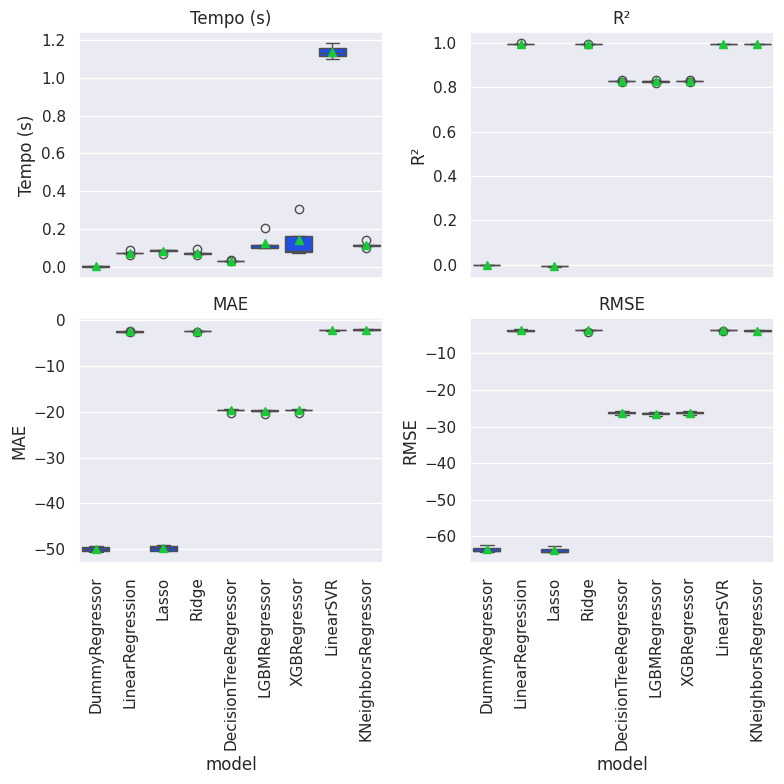

In [9]:
plot_model_metrics_comparison(df_resultados)

In [10]:
param_grid = {
    "regressor__reg__alpha": [0.1, 0.5, 1, 2, 5, 10]
}

In [11]:
grid_search = run_grid_search_cv(
    regressor=Ridge(),
    preprocessor=preprocessing,
    target_transformer=QuantileTransformer(output_distribution="normal"),
    param_grid=param_grid,
)

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa...ion='normal'))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__reg__alpha': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['r2', 'neg_mean_absolute_error', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [12]:
grid_search.fit(X, y)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa...ion='normal'))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__reg__alpha': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['r2', 'neg_mean_absolute_error', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

## 7. Analysis of Best Results

We inspect the parameters and resulting scores from the best run.

In [13]:
# Checking the best hyperparameters found
grid_search.best_params_

{'regressor__reg__alpha': 0.1}

In [14]:
grid_search.best_score_

np.float64(-3.843543775950954)

## 8. Coefficient and Importance Analysis

We analyze the weights assigned by the model to each variable to understand which impact emissions the most.

In [15]:
# Extraction and visualization of the final model coefficients
coefs = get_coefficients_dataframe(
    grid_search.best_estimator_.regressor_["reg"].coef_,
    grid_search.best_estimator_.regressor_["preprocessor"].get_feature_names_out(),
)

coefs

,coeficiente
onehot__fuel_type_ethanol,-2.152526
onehot__fuel_type_premium_gasoline,-0.632284
onehot__fuel_type_reg_gasoline,-0.617015
power_transform__combined_l_100_km,-0.157998
onehot__vehicle_class_grouped_special_purpose,-0.042937
onehot__vehicle_class_grouped_suv,-0.022148
onehot__transmission_M,-0.009448
onehot__vehicle_class_grouped_pickup_truck,-0.008720
onehot__vehicle_class_grouped_station_wagon,-0.008135
onehot__transmission_AS,-0.005463


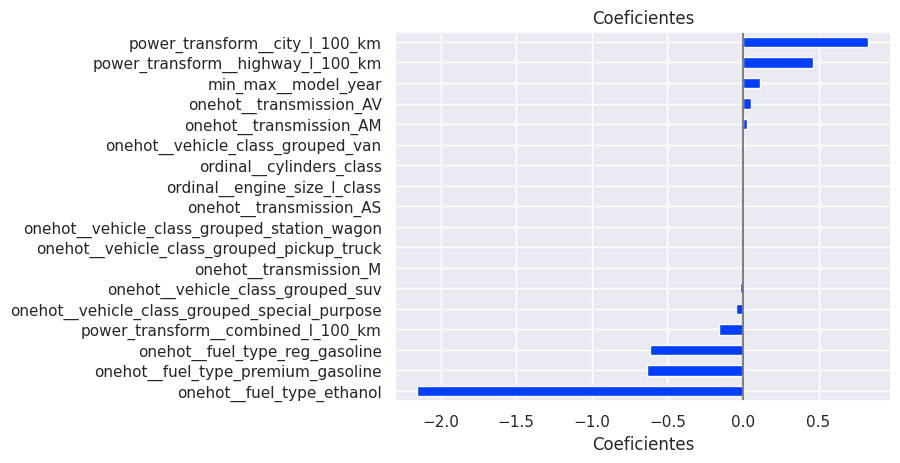

In [16]:
plot_coefficients(coefs)

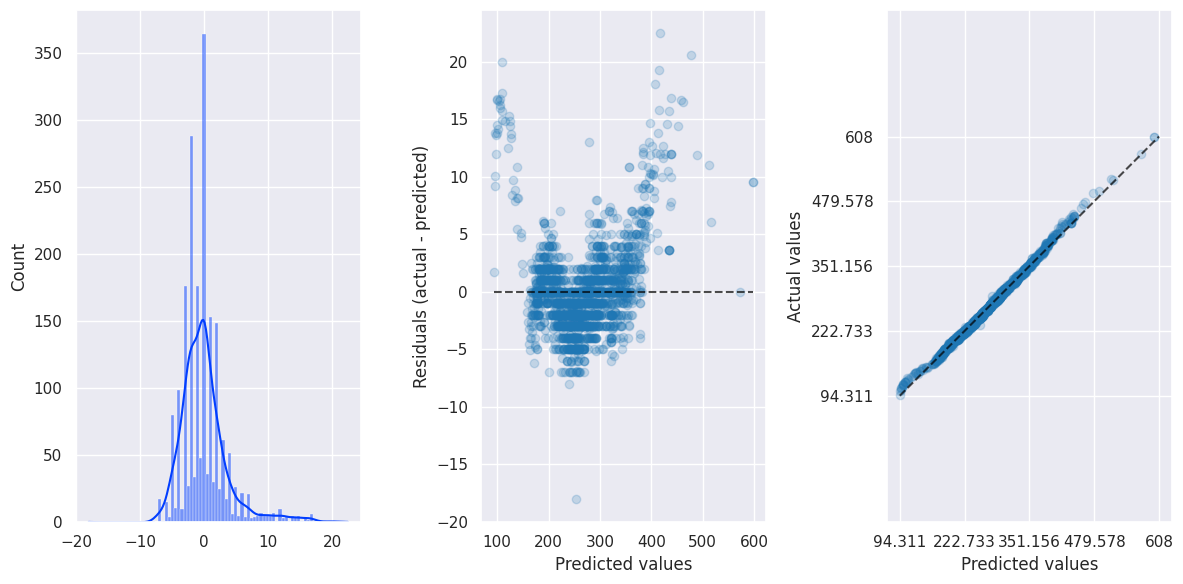

In [17]:
plot_estimator_residuals(grid_search.best_estimator_, X, y, fracao_amostra=0.1, eng_formatter=True)

In [18]:
dump(grid_search.best_estimator_, FINAL_MODEL)

['/home/evlos/myprojects/Ciencias_Dados_Impressionador/Project_CO2_emissions/models/ridge.joblib']